<a href="https://colab.research.google.com/github/zen-code11/GC-Data/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Frammer GC dataset/combined_data(2025-3-1-2026-2-28) by user.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df

,User,Uploaded Count,Created Count,Published Count,Uploaded Duration (hh:mm:ss),Created Duration (hh:mm:ss),Published Duration (hh:mm:ss)
0,Chandan,489,2152,19,100:43:58,209:18:47,01:13:40
1,QA-Purushottam,309,1227,13,33:08:48,55:19:21,00:21:34
2,vikas.s@moolya.com,265,1094,4,61:22:20,101:55:47,00:15:23
3,Sandeep Belaki,253,1039,7,39:59:44,84:32:25,00:08:12
4,Nitesh,224,959,0,59:57:41,87:54:11,00:00:00
5,Abhishek,201,408,8,19:25:46,26:56:37,00:25:04
6,Auto Upload,185,220,0,41:52:06,42:52:30,00:00:00
7,Subhesh,184,489,7,21:36:47,30:19:43,00:13:00
8,Trivendra,179,825,3,61:09:11,111:06:20,00:10:00
9,Dheeraj Pareek(QA theveritycorp.com),166,482,2,16:07:52,32:23:39,00:02:13


In [ ]:
df.isnull().sum() #checking if any data is missing or not

,0
User,0
Uploaded Count,0
Created Count,0
Published Count,0
Uploaded Duration (hh:mm:ss),0
Created Duration (hh:mm:ss),0
Published Duration (hh:mm:ss),0


In [ ]:
df.shape #dimensions of the dataform

(45, 7)

In [ ]:
df.dtypes #checking the datatypes of each column


,0
User,object
Uploaded Count,int64
Created Count,int64
Published Count,int64
Uploaded Duration (hh:mm:ss),object
Created Duration (hh:mm:ss),object
Published Duration (hh:mm:ss),object


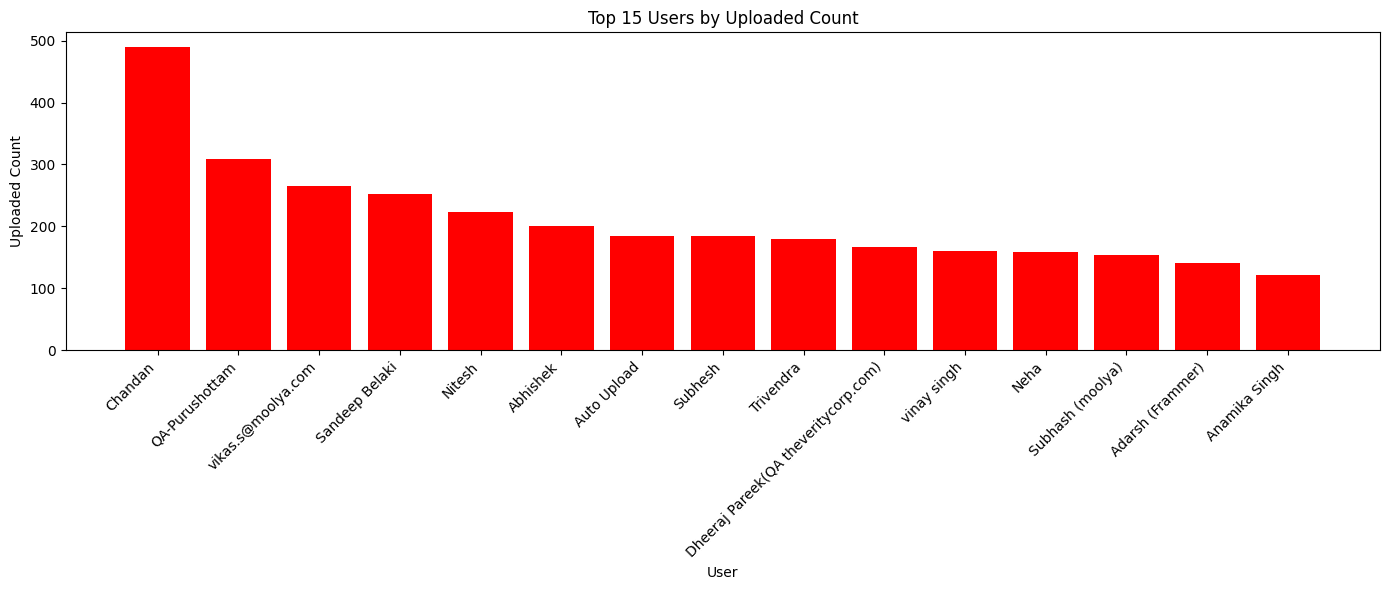

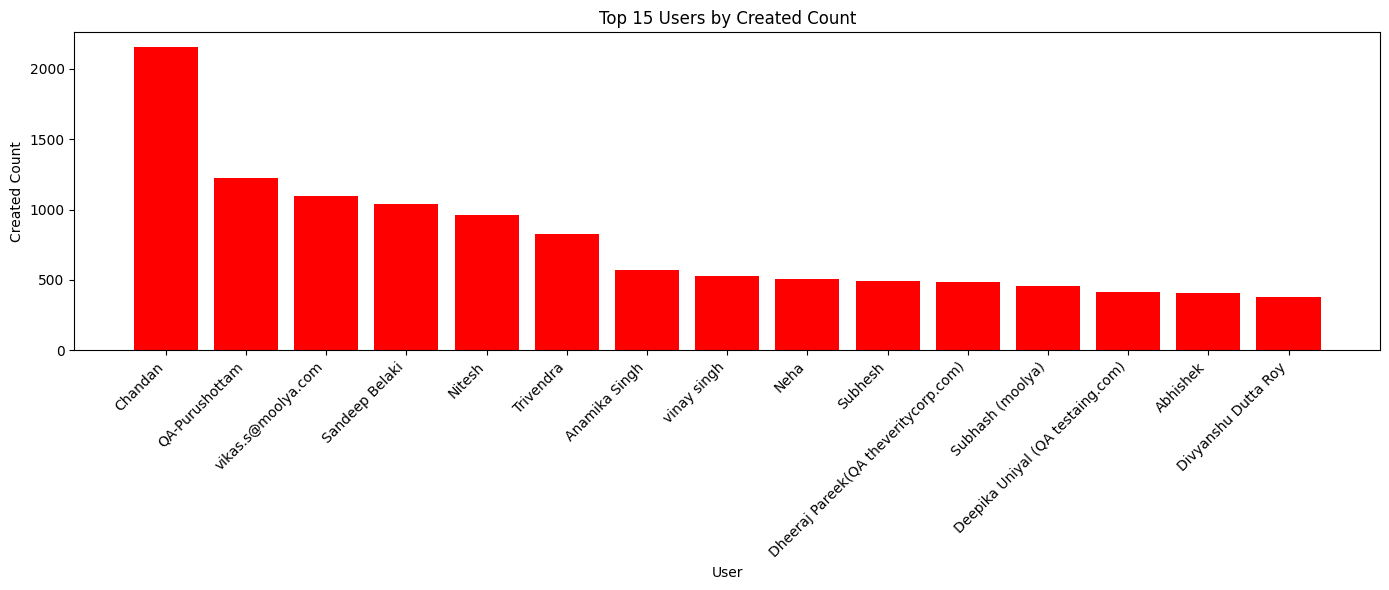

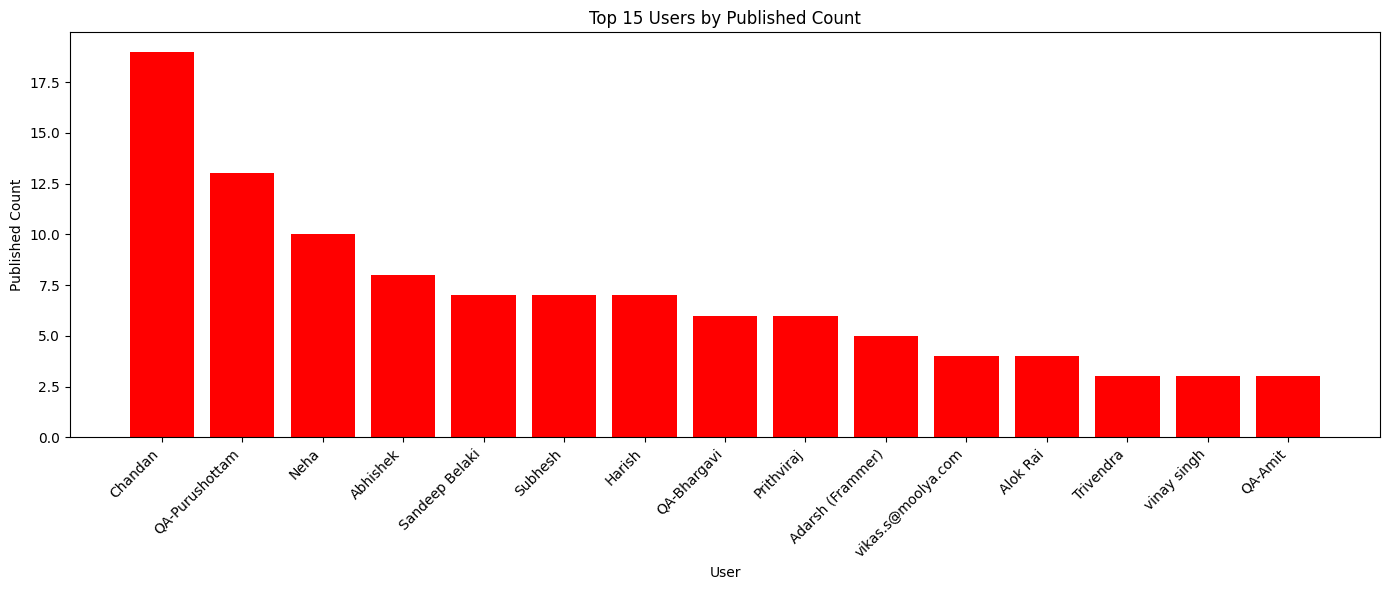

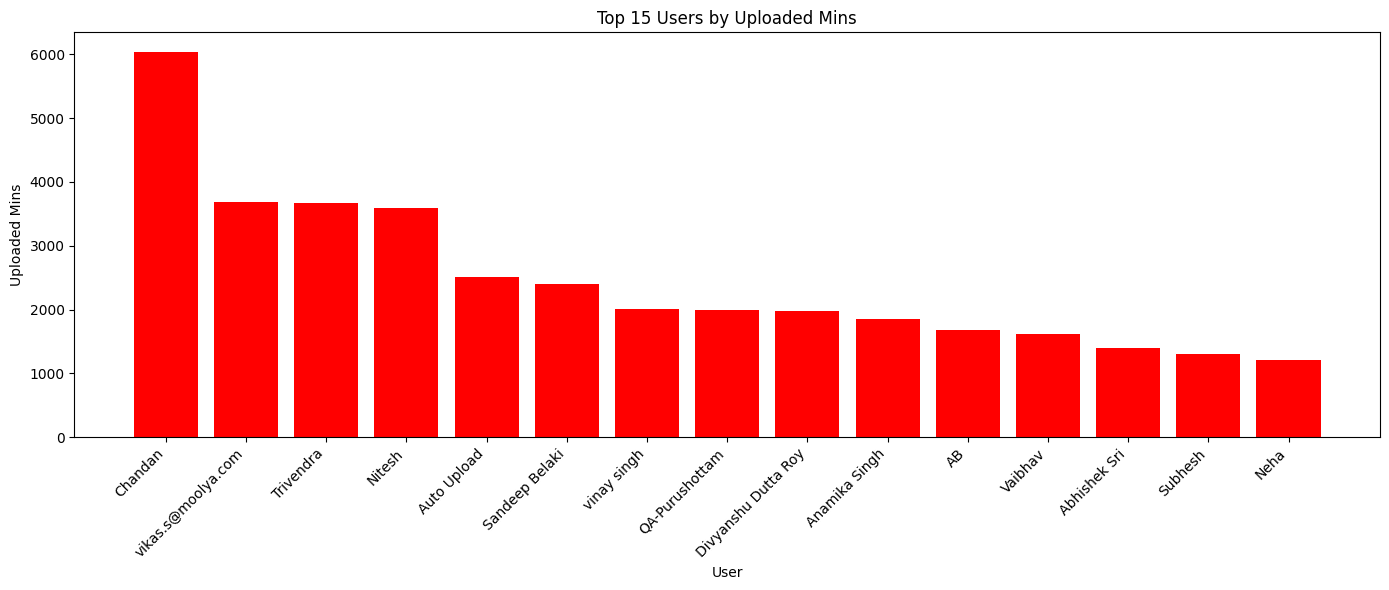

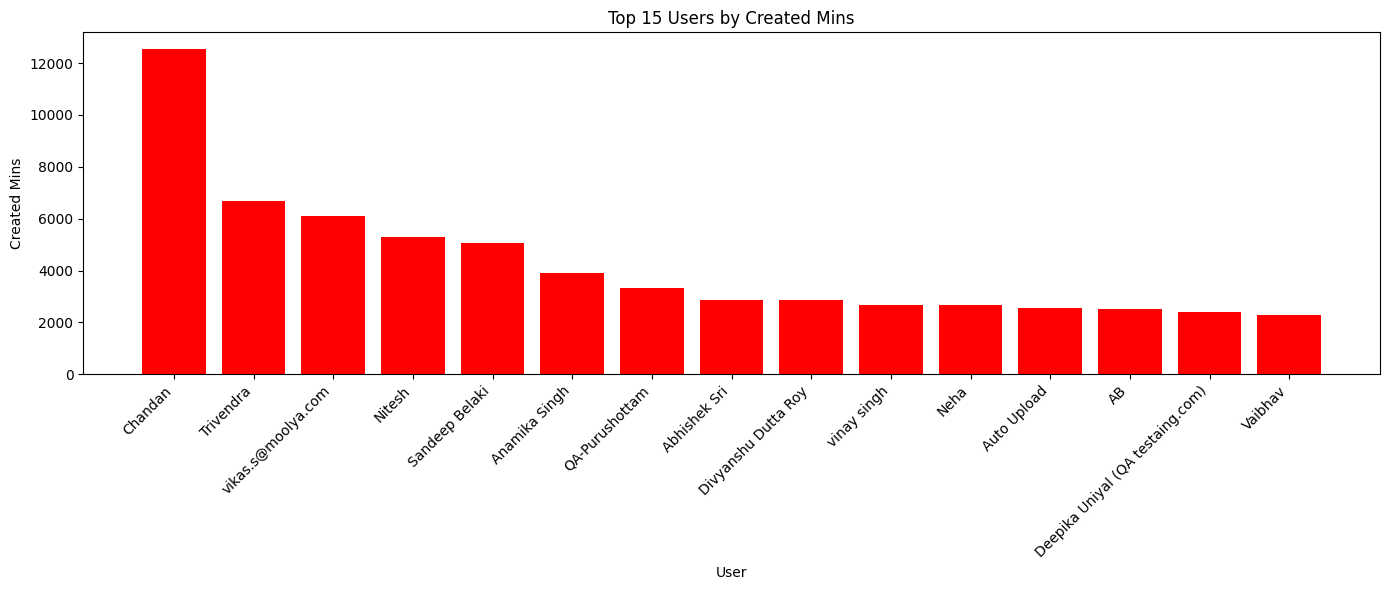

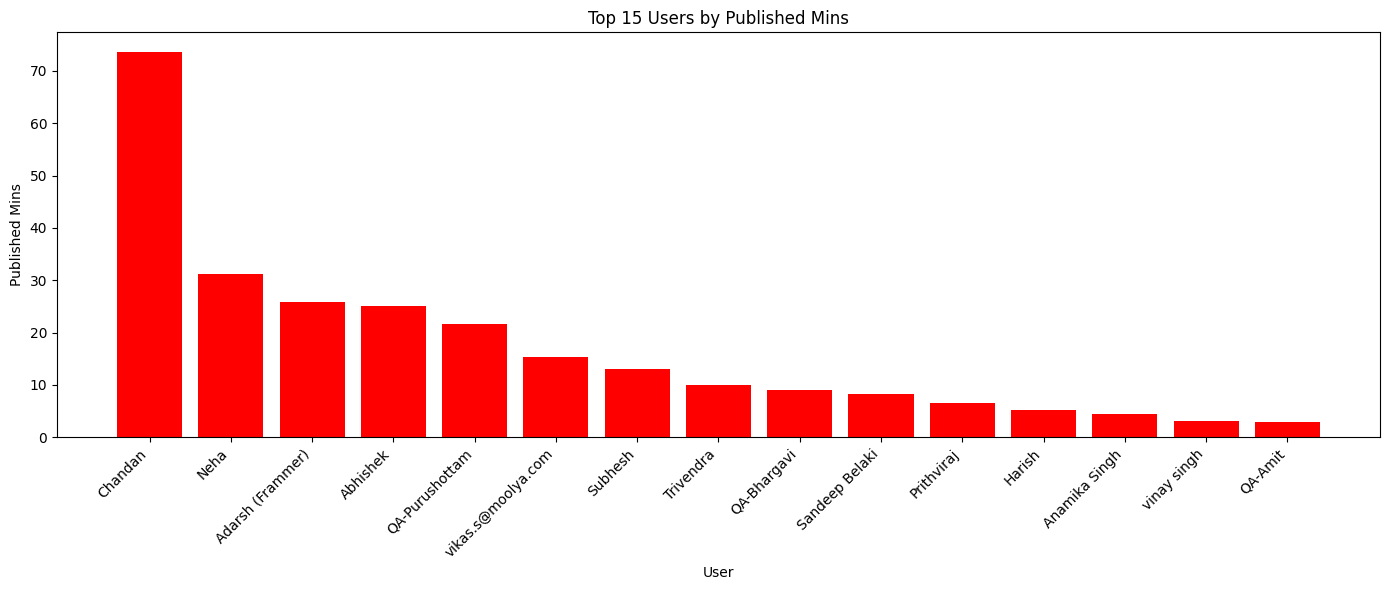

In [ ]:
#we have to convert the duration which is in object form to numeric values
def to_minutes(t):
    try:
        h, m, s = str(t).strip().split(':')
        return int(h)*60 + int(m) + int(s)/60
    except:
        return 0

#passing the function for converting mins for object to int64 in mins
df['Uploaded Mins'] = df['Uploaded Duration (hh:mm:ss)'].apply(to_minutes)
df['Created Mins'] = df['Created Duration (hh:mm:ss)'].apply(to_minutes)
df['Published Mins'] = df['Published Duration (hh:mm:ss)'].apply(to_minutes)

# Converting count columns to numeric
df['Uploaded Count'] = pd.to_numeric(df['Uploaded Count'])
df['Created Count'] = pd.to_numeric(df['Created Count'])
df['Published Count'] = pd.to_numeric(df['Published Count'])

#function to plot those six columns in y-axis vs users in x-axis
def plot_top15(df, column, color='red'):
    top15 = df.nlargest(15, column)

    plt.figure(figsize=(14, 6))
    plt.bar(top15['User'], top15[column], color=color)
    plt.title(f'Top 15 Users by {column}')
    plt.xlabel('User')
    plt.ylabel(column)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

columns = ['Uploaded Count', 'Created Count', 'Published Count',
           'Uploaded Mins', 'Created Mins', 'Published Mins']

for col in columns:
    plot_top15(df, col)


From these bar graphs we understand that more or less these bar graphs have correlation that some names perform the same way in all the columns now we will observe it to what scale they are related to each other.

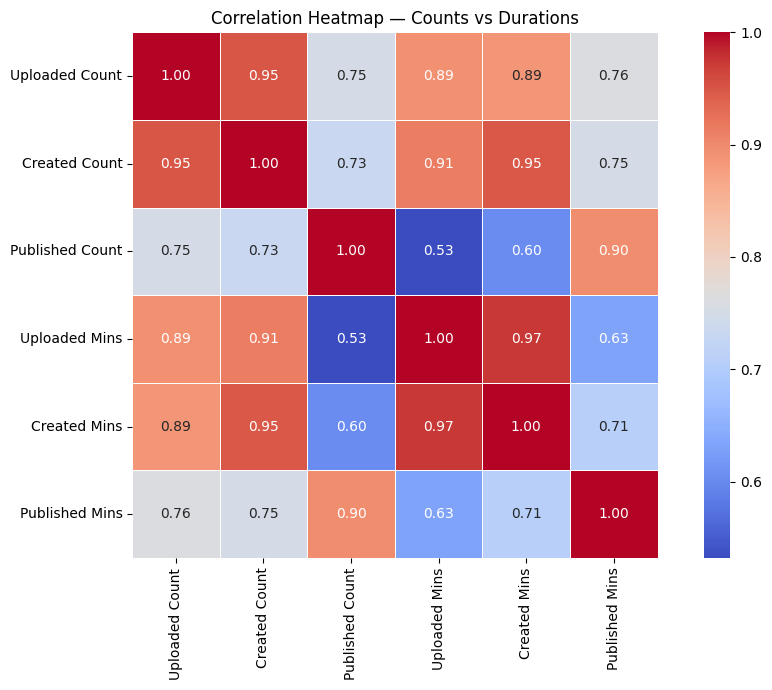

In [ ]:
corr_df = df[['Uploaded Count', 'Created Count', 'Published Count',
              'Uploaded Mins', 'Created Mins', 'Published Mins']]

#here we use the library seaborn to find correlation between these six columns
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — Counts vs Durations')
plt.tight_layout()
plt.show()

We can say that there is high correlation between creating and uploading but when we take publishing into account we cannot say the same thing.
Looking at the correlation map we can see there is almost 20% gap between uploaded,created count with published count but when we see the same in mins the gap is almost 35%.

In [ ]:
df['Publish Rate (%)'] = (df['Published Count'] / df['Created Count'] * 100).round(2)
